In [ ]:
"""
MAE 6760 Model Based Estimation
Cornell University
M Campbell

Homework #4
Problem #2: Sigma Point Filter (SPF)
  two state Van der Pol oscillator nonlinear system
    uses the following Python functions:
        plot_openloop.py
        plot_estimator.py
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from HW5.plot_openloop import plot_openloop
from HW5.plot_estimator import plot_estimator




In [ ]:
# ─────────────────────────────────────────────
# Internal helper functions
# ─────────────────────────────────────────────

def vanderpol(t, x, mu, w):
    """Nonlinear differential equations for the Van der Pol oscillator."""
    xdot1 = x[1]
    xdot2 = -x[0] + mu * (1 - x[0] ** 2) * x[1] + w
    return [xdot1, xdot2]


def predict_state_vdp(Xk, mu, tk, tkp1):
    """
    For the Van der Pol oscillator.
    Discrete prediction of state at k+1 via solve_ivp (ode45 equivalent).
    Xk is an (nx x nsp) array.
    """
    nx, nsp = Xk.shape
    Xkp1 = np.zeros_like(Xk)
    tspan = [tk, tkp1]
    for i in range(nsp):
        xinit = Xk[:, i]
        wk = 0.0
        sol = solve_ivp(vanderpol, tspan, xinit, args=(mu, wk),
                        method='RK45', dense_output=False)
        Xkp1[:, i] = sol.y[:, -1]
    return Xkp1


def predict_msmt_vdp(Xkp1):
    """
    For the Van der Pol oscillator.
    Discrete prediction of measurement zhat at k+1.
    Xkp1 is an (nx x nsp) array.
    """
    H = np.array([[1, 0]])
    return H @ Xkp1  # (1 x nsp)

def spf_vdp(xEst, PxEst, U, Q, ffun, z, R, hfun, tk, tkp1, mu, nsig):
    """
    SPF with additive noise: passes mu for VDP oscillator.

    One iteration of SPF, including prediction and correction.
    Assumes additive process and sensor noise.

    INPUTS
        xEst   : state mean estimate at time k  (nx,)
        PxEst  : state covariance at time k     (nx, nx)
        U      : control inputs (unused here)
        Q      : process noise covariance       (nx, nx)
        ffun   : process model function
        z      : scalar observation at k+1
        R      : scalar measurement noise variance at k+1
        hfun   : observation model function
        tk     : current time
        tkp1   : next time
        mu     : Van der Pol constant
        nsig   : sigma point scaling factor

    OUTPUTS
        xEst      : updated state mean at k+1
        PxEst     : updated state covariance at k+1
        xPred     : a priori state mean at k+1
        zPred     : predicted measurement at k+1
        innovation: innovation scalar
    """
    nx = len(xEst)
    nsp = 2 * nx + 1
    ensp = np.ones((1, nsp))

    # Weighting matrices
    Wi   = 0.5 / nsig ** 2
    W0M  = (nsig ** 2 - nx) / nsig ** 2
    W0C  = (nsig ** 2 - nx) / nsig ** 2 + 3 - nsig ** 2 / nx
    WM   = np.concatenate([[W0M], np.ones(2 * nx) * Wi])          # (nsp,)
    WC   = np.concatenate([[W0C], np.ones(2 * nx) * Wi])          # (nsp,)

    # ── Initialise sigma points ──────────────────────────────────────────
    Psqrtm = nsig * np.linalg.cholesky(PxEst)                     # lower triangular
    cols = np.hstack([np.zeros((nx, 1)), -Psqrtm, Psqrtm])        # (nx, nsp)
    xSigmaPts = cols + xEst[:, None] * ensp

    # ── Prediction of sigma points ───────────────────────────────────────
    xPredSigmaPts = ffun(xSigmaPts, mu, tk, tkp1)                 # (nx, nsp)

    # A priori mean
    xPred = xPredSigmaPts @ WM                                     # (nx,)

    # A priori covariance
    exSigmaPts = xPredSigmaPts - xPred[:, None] * ensp
    PxxPred = exSigmaPts @ np.diag(WC) @ exSigmaPts.T + Q

    # ── Measurement update ───────────────────────────────────────────────
    # Re-initialise sigma points with predicted covariance
    Psqrtm = nsig * np.linalg.cholesky(PxxPred)
    exSigmaPts = np.hstack([np.zeros((nx, 1)), -Psqrtm, Psqrtm])
    xPredSigmaPts = exSigmaPts + xPred[:, None] * ensp

    # Propagate through measurement model
    zPredSigmaPts = hfun(xPredSigmaPts)                            # (1, nsp)

    # Predicted measurement mean
    zPred = (zPredSigmaPts @ WM).item()                            # scalar

    # Kalman gain
    ezSigmaPts = zPredSigmaPts - zPred * ensp                      # (1, nsp)
    PxzPred = exSigmaPts @ np.diag(WC) @ ezSigmaPts.T             # (nx, 1)
    Pyy = (ezSigmaPts @ np.diag(WC) @ ezSigmaPts.T + R).item()    # scalar
    K = PxzPred / Pyy                                              # (nx, 1)

    # Covariance update
    PxEst = PxxPred - K @ PxzPred.T

    # Innovation and mean update
    innovation = z - zPred
    xEst = xPred + (K * innovation).ravel()

    return xEst, PxEst, xPred, zPred, innovation


## Everything above here is provided, no editing required

In [ ]:
def predict_state_vdp_euler(Xk, mu, tk, tkp1):
    """
    For the Van der Pol oscillator.
    Discrete prediction of state at k+1 via Euler integration.
    Xk is an (nx x nsp) array.
    """
    nx, nsp = Xk.shape
    Xkp1 = np.zeros_like(Xk)
    tspan = [tk, tkp1]
    dt = tspan[1]-tspan[0]
    N_int = 2 # number of time steps to do euler integration for, might need tuning
    dt = dt / N_int
    
    for i in range(nsp):
        sp = Xk[:,i].copy()
        wk=0
        t = tk.copy()
        for j in range(N_int):
            vp_eval = vanderpol(t,sp,mu,wk)
            sp += np.array(vp_eval)*dt # wrap list as array to make multiplication easy
            t += dt
        
        Xkp1[:, i] = sp
    
    return Xkp1

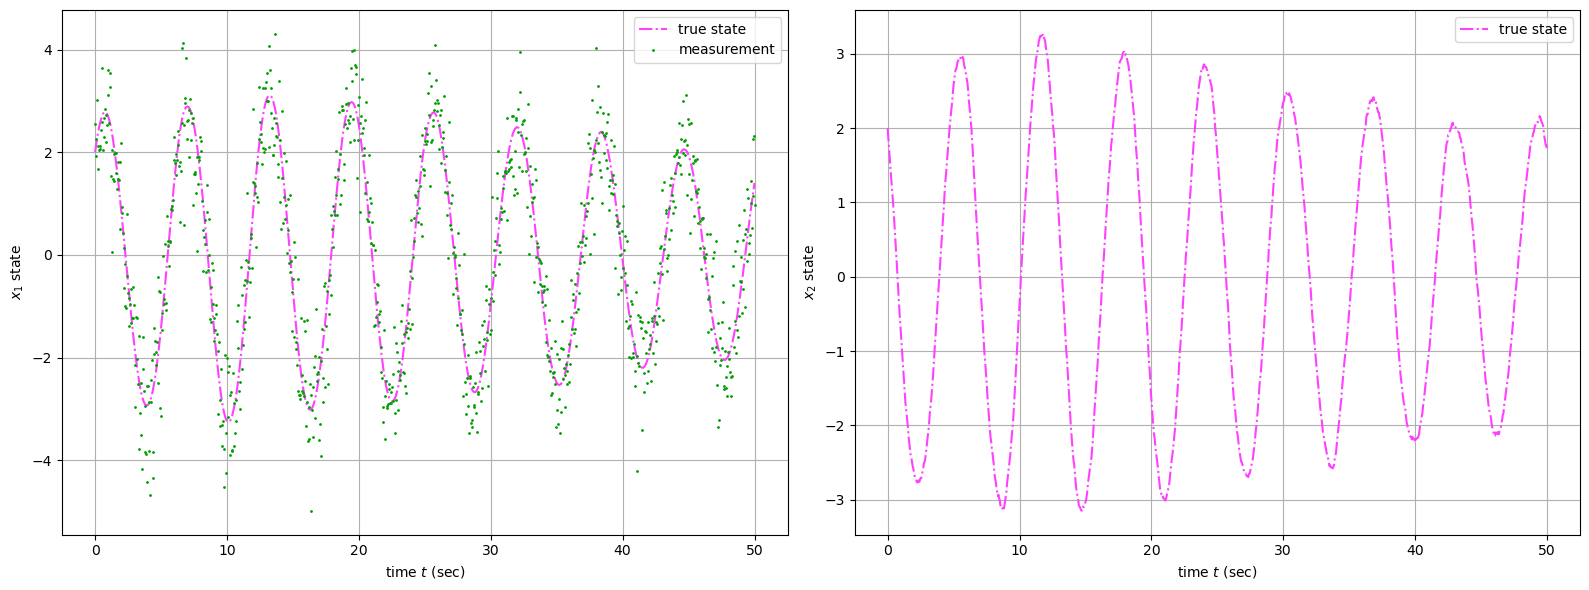

In [ ]:
# -------------------------------------------------
# User input parameters
# -------------------------------------------------

# SWITCH THESE
mu = 0.01                       # Van der Pol constant
#mu = 5.0

# EDIT THIS
nsig = 0.1  ## YOUR CODE HERE             # number of sigmas in SPF

# SWITCH THESE
#ffun = predict_state_vdp        # runga kutta prediction step
ffun = predict_state_vdp_euler  # runga kutta prediction step

hfun = predict_msmt_vdp         # predicted measurement output

# Initialization
twosigp = 1.0 # 2 sigma initialization for position
twosigv = 0.5 # " for velocity
sigpsq = (twosigp/2)**2
sigvsq = (twosigv/2)**2
P0 = np.diag([sigpsq,sigvsq]) # initial convariance


# ─────────────────────────────────────────────
# Main script
# ─────────────────────────────────────────────

rng = np.random.default_rng(10)

# Time vector
dt = 0.05
tf = 50.0
t = np.arange(0, tf + dt, dt)
nt = len(t)

# Process noise
Qc = 0.01
w = rng.standard_normal(nt) * (np.sqrt(Qc) / np.sqrt(dt))
Qd = Qc / dt
G = np.array([[0.0], [dt]])

# Simulate Van der Pol via solve_ivp (ode45 equivalent)
x0 = np.array([2.0, 2.0])
nx = 2
x_true = np.zeros((nx, nt))
x_true[:, 0] = x0

for k in range(nt - 1):
    x_init = x_true[:, k]
    wk = w[k]
    tspan = [t[k], t[k + 1]]
    sol = solve_ivp(vanderpol, tspan, x_init, args=(mu, wk), method='RK45')
    x_true[:, k + 1] = sol.y[:, -1]

# Noisy measurements
R = 0.5
v = np.sqrt(R) * rng.standard_normal(nt)
z = x_true[0, :] + v

# ── Open-loop plots ──────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
fig1.subplots_adjust(wspace=0.3)

plot_openloop(t, x_true[0, :], z=z, ax=axes1[0])
axes1[0].set_ylabel(r'$x_1$ state')

plot_openloop(t, x_true[1, :], ax=axes1[1])
axes1[1].set_ylabel(r'$x_2$ state')

plt.tight_layout()



0.1


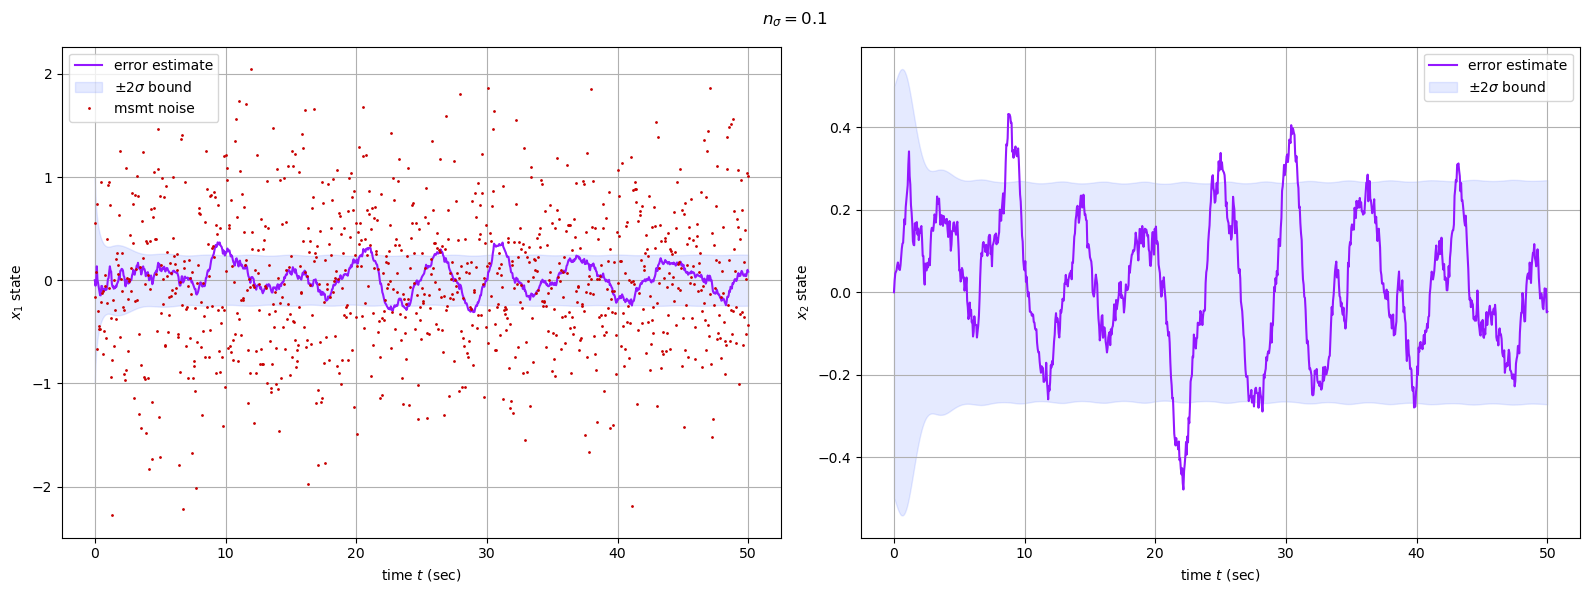

In [57]:
# ── Sigma Point Filter ───────────────────────────────────────────────────
print(nsig)
xhatp = np.zeros((nx, nt));  xhatp[:, 0] = x0
Pp    = np.zeros((nx, nx, nt));  Pp[:, :, 0] = P0
xhatu = xhatp.copy()
Pu    = Pp.copy()

for k in range(nt - 1):
    zkp1 = z[k + 1]
    Qx = G @ np.array([[Qd]]) @ G.T
    xhatu[:, k + 1], Pu[:, :, k + 1], xPred, zPred, innovation = spf_vdp(
        xhatu[:, k], Pu[:, :, k], None, Qx,
        ffun, zkp1, R, hfun,
        t[k], t[k + 1], mu, nsig
    )

# ── Estimator plots ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.subplots_adjust(wspace=0.3)

plt.suptitle(r"$n_\sigma =" + str(nsig) + "$")

plot_estimator(t, xhatu[0, :], Pu[0, 0, :], x_true[0, :],
               plot_type='error', z=z, ax=axes2[0])
axes2[0].set_ylabel(r'$x_1$ state')

plot_estimator(t, xhatu[1, :], Pu[1, 1, :], x_true[1, :],
               plot_type='error', ax=axes2[1])
axes2[1].set_ylabel(r'$x_2$ state')

plt.tight_layout()

plt.show()